# Curso de FEC - Unidad 1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
from scipy.integrate import quad
from scipy.optimize import brentq
import itertools

rng = np.random.default_rng(2026) # para poder reproducir los resultados más adelante
plt.rcParams["figure.figsize"] = (7, 4.3)
plt.rcParams["axes.grid"] = True

def Q(x):
    '''Función Q gaussiana: Q(x) = P(N(0,1) > x) = 0.5 erfc(x/sqrt(2)).'''
    return 0.5 * erfc(np.asarray(x, float) / np.sqrt(2))

def Hb(p):
    '''Entropía binaria H(p) en bits, con H(0)=H(1)=0.'''
    p = np.asarray(p, float)
    out = np.zeros_like(p)
    m = (p > 0) & (p < 1)
    out[m] = -p[m]*np.log2(p[m]) - (1-p[m])*np.log2(1-p[m])
    return out

## 1. BER de modulación BPSK sobre AWGN

Para BPSK con detección óptima sobre AWGN, la probabilidad de error de bit **sin codificar** es
$$p = Q\!\left(\sqrt{2\,E_b/N_0}\right).$$
Comparamos la curva teórica con una simulación de Monte Carlo (mapeo $0\to+1$, $1\to-1$, ruido gaussiano, decisión por signo).

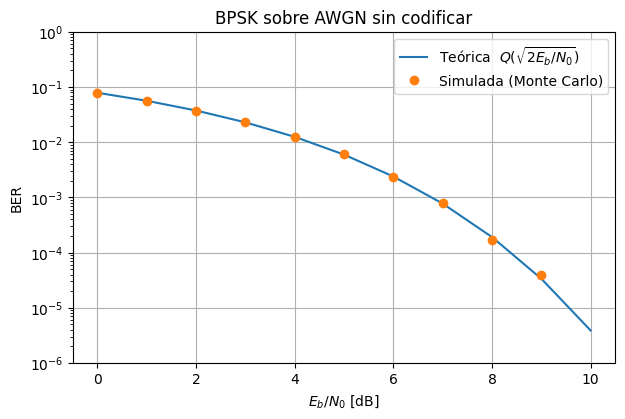

In [ ]:
EbN0_dB = np.arange(0, 11)
EbN0    = 10**(EbN0_dB/10)

# Curva teórica: con Es = Eb para BPSK sin codificar
ber_teo = Q(np.sqrt(2*EbN0))

def simular_ber_bpsk(EbN0_lin, n_bits=300_000):
    bits  = rng.integers(0, 2, n_bits)
    x     = 1 - 2*bits                      # 0->+1, 1->-1
    sigma = np.sqrt(1/(2*EbN0_lin))         # Eb=1  =>  N0 = 1/(Eb/N0)
    y     = x + sigma*rng.standard_normal(n_bits)
    bits_hat = (y < 0).astype(int)          # decisión por signo
    return np.mean(bits_hat != bits)

ber_sim = [simular_ber_bpsk(e) for e in EbN0]

plt.semilogy(EbN0_dB, ber_teo, '-',  label=r'Teórica  $Q(\sqrt{2E_b/N_0})$')
plt.semilogy(EbN0_dB, ber_sim, 'o',  label='Simulada (Monte Carlo)')
plt.xlabel(r'$E_b/N_0$ [dB]');
plt.ylabel('BER');
plt.ylim(1e-6, 1)
plt.title('BPSK sobre AWGN sin codificar');
plt.legend();

## 2. Código de repetición (3,1) sobre un canal binario (BSC)

El código de repetición envía $0\to000$, $1\to111$ y decide por **voto por mayoría**. Sobre un BSC con probabilidad de transición $p$, la palabra se decodifica mal solo si se invierten 2 o 3 bits:
$$P_{\text{err}} = 3p^2(1-p) + p^3.$$
Como $P_{\text{err}} < p$ para todo $p<1/2$, la redundancia reduce la tasa de error **a igual $p$** (el costo es triplicar el ancho de banda, $R=1/3$).

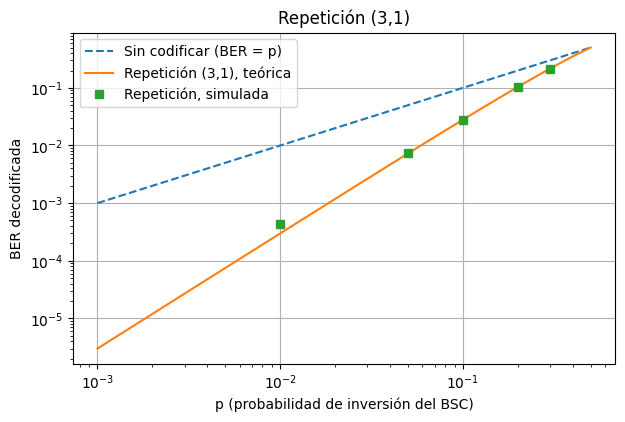

In [ ]:
def ber_repeticion(p):
    return 3*p**2*(1-p) + p**3 # error si 2 o 3 de 3 bits fallan

def simular_repeticion(p, n_msg=200_000):
    msg  = rng.integers(0, 2, n_msg)
    cw   = np.repeat(msg, 3).reshape(n_msg, 3)          # 000 o 111
    flip = (rng.random((n_msg, 3)) < p).astype(int)     # ruido BSC
    recv = cw ^ flip
    dec  = (recv.sum(axis=1) >= 2).astype(int)          # mayoría
    return np.mean(dec != msg)

p_grid = np.logspace(-3, np.log10(0.5), 60)
p_chk  = [0.01, 0.05, 0.1, 0.2, 0.3]

plt.loglog(p_grid, p_grid,             '--', label='Sin codificar (BER = p)')
plt.loglog(p_grid, ber_repeticion(p_grid), '-', label='Repetición (3,1), teórica')
plt.loglog(p_chk, [simular_repeticion(p) for p in p_chk], 's', label='Repetición, simulada')
plt.xlabel('p (probabilidad de inversión del BSC)');
plt.ylabel('BER decodificada')
plt.title('Repetición (3,1)');
plt.legend();

## 3. Distancia de Hamming, $d_{\min}$ y capacidad del código

- **Peso**: cantidad de componentes no nulas.
- **Distancia de Hamming**: posiciones en que difieren dos palabras.
- **Distancia mínima** $d_{\min}$: la menor entre palabras de código distintas.
- Detecta hasta $d_{\min}-1$ errores; corrige hasta $t=\lfloor(d_{\min}-1)/2\rfloor$.

In [ ]:
def peso(c):
  return int(np.sum(c))

def dist_hamming(a, b):
  return int(np.sum(np.asarray(a) != np.asarray(b)))

def dmin_codebook(C):
    C = [np.asarray(c) for c in C]
    return min(dist_hamming(C[i], C[j]) for i in range(len(C)) for j in range(i+1, len(C)))

def resumen(nombre, C):
    d = dmin_codebook(C)
    print(f"{nombre:26s} | palabras={len(C):3d} | dmin={d} "f"| detecta={d-1} | corrige t={(d-1)//2}")

# Repetición (3,1)
rep = [[0,0,0], [1,1,1]]
# Paridad par (4,3): 3 bits de info + 1 de paridad
par = [list(b) + [sum(b) % 2] for b in itertools.product([0,1], repeat=3)]

print("Ejemplo distancia de Hamming entre 000 y 111:", dist_hamming([0,0,0],[1,1,1]))
resumen("Repetición (3,1)", rep)
resumen("Paridad simple (4,3)", par)

Ejemplo distancia de Hamming entre 000 y 111: 3
Repetición (3,1)           | palabras=  2 | dmin=3 | detecta=2 | corrige t=1
Paridad simple (4,3)       | palabras=  8 | dmin=2 | detecta=1 | corrige t=0


## 4. Entrelazado

Un **intercalador de bloque** escribe las palabras por filas y las transmite por columnas. Así, símbolos contiguos en el canal pertenecen a palabras distintas: una ráfaga concentrada se reparte en **≤1 error por palabra** al des-intercalar.

Errores por palabra sin entrelazado: [0, 5, 0, 0, 0]  -> máx 5
Errores por palabra con entrelazado: [1, 1, 1, 1, 1]  -> máx 1


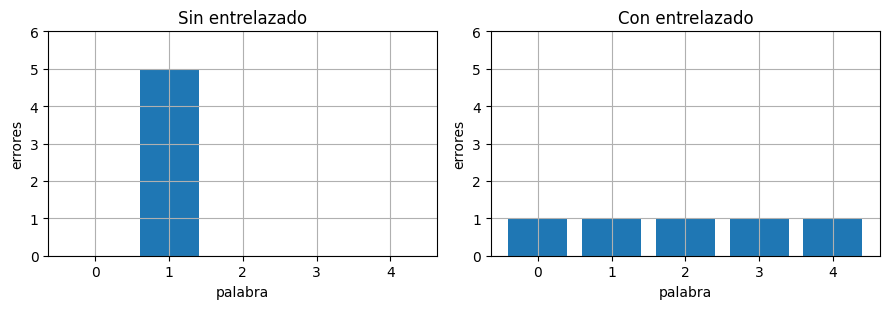

In [ ]:
n_words, n_len = 5, 8
words = rng.integers(0, 2, (n_words, n_len))     # 5 palabras de 8 bits

burst_ini, burst_len = 10, 5                      # ráfaga contigua en el canal

# sin entrelazado: se transmite palabra por palabra
tx_sin      = words.flatten()
rx_sin      = tx_sin.copy(); rx_sin[burst_ini:burst_ini+burst_len] ^= 1
err_sin     = (rx_sin.reshape(n_words, n_len) != words).sum(axis=1)

# con entrelazado de bloque: escribir filas, leer columnas ---
tx_int      = words.T.flatten()
rx_int      = tx_int.copy(); rx_int[burst_ini:burst_ini+burst_len] ^= 1
rx_words    = rx_int.reshape(n_len, n_words).T
err_int     = (rx_words != words).sum(axis=1)

print("Errores por palabra sin entrelazado:", err_sin.tolist(), " -> máx", err_sin.max())
print("Errores por palabra con entrelazado:", err_int.tolist(), " -> máx", err_int.max())

fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].bar(range(n_words), err_sin); ax[0].set_title('Sin entrelazado')
ax[1].bar(range(n_words), err_int); ax[1].set_title('Con entrelazado')
for a in ax:
    a.set_xlabel('palabra');
    a.set_ylabel('errores');
    a.set_ylim(0, burst_len+1)
plt.tight_layout();